# Carleman lifting: nonlinear pendulum

This notebook benchmarks the exact nonlinear pendulum solved with Para-Seq's RK4 + full DEER path against a finite Carleman lift propagated with Para-Seq's dense associative-scan linear ODE utilities.

The horizon is ten seconds. The lifted state is restarted from its own predicted first block every eight time steps to control finite-section drift.


In [1]:
from pathlib import Path
import sys
import time
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from scipy.integrate import solve_ivp

repo_root = next(
    path
    for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "src" / "ode_solvers").is_dir()
)
sys.path.insert(0, str(repo_root))

from src.ode_solvers import (
    discretize_lti_zoh,
    linear_affine_scan,
    solve_ode_fixed_step,
)

torch.set_default_dtype(torch.float64)
dtype = torch.float64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

print(f"Repository: {repo_root}")
print(f"Device:     {device}")
print(f"Dtype:      {dtype}")


Repository: /mnt/c/Users/Banaan/Documents/Github/IDK/Para-Seq
Device:     cuda
Dtype:      torch.float64


## Model and finite Carleman system

With angle \(q\), velocity \(v\), and \(\omega_0^2=g/\ell\),

\[
\dot q=v,
\qquad
\dot v=-\omega_0^2\sin q.
\]

Use \(z_k=[q^k,q^{k-1}v,\ldots,v^k]^\mathsf T\). For \(q^iv^j\), \(i+j=k\),

\[
\frac{d}{dt}(q^iv^j)
=iq^{i-1}v^{j+1}
-j\omega_0^2\sum_{r=0}^{\infty}
\frac{(-1)^r}{(2r+1)!}q^{i+2r+1}v^{j-1}.
\]

The kinematic term stays in degree \(k\); the sine terms couple degree \(k\) to \(k+2r\). The finite section keeps only total degree at most \(N\).


In [2]:
gravity = 9.81
length = 1.0
omega_squared = gravity / length

initial_state = np.array([0.7, 0.0], dtype=np.float64)
final_time = 10.0
num_time_points = 513
carleman_order = 10
carleman_relift_steps = 8

times = np.linspace(0.0, final_time, num_time_points, dtype=np.float64)


def pendulum_rhs_torch(time, state, control):
    angle = state[..., 0]
    velocity = state[..., 1]
    return torch.stack((velocity, -omega_squared * torch.sin(angle)), dim=-1)


def pendulum_rhs_scipy(time, state):
    angle, velocity = state
    return np.array([velocity, -omega_squared * np.sin(angle)], dtype=np.float64)


In [3]:
def pendulum_carleman_matrix(order):
    offsets = {}
    dimension = 0
    for degree in range(1, order + 1):
        offsets[degree] = dimension
        dimension += degree + 1

    matrix = np.zeros((dimension, dimension), dtype=np.float64)
    for degree in range(1, order + 1):
        row_offset = offsets[degree]
        for velocity_power in range(degree + 1):
            angle_power = degree - velocity_power
            row = row_offset + velocity_power
            if angle_power > 0:
                matrix[row, row_offset + velocity_power + 1] += angle_power
            if velocity_power > 0:
                sine_index = 0
                while degree + 2 * sine_index <= order:
                    target_degree = degree + 2 * sine_index
                    coefficient = (
                        -velocity_power * omega_squared * (-1) ** sine_index
                        / math.factorial(2 * sine_index + 1)
                    )
                    matrix[row, offsets[target_degree] + velocity_power - 1] += coefficient
                    sine_index += 1
    return matrix


def pendulum_lift(state, order):
    angle = state[0]
    velocity = state[1]
    values = [
        angle ** (degree - velocity_power) * velocity**velocity_power
        for degree in range(1, order + 1)
        for velocity_power in range(degree + 1)
    ]
    return torch.stack(values) if torch.is_tensor(state) else np.asarray(values)


def truncated_sine(angle, order):
    return sum(
        (-1) ** index * angle ** (2 * index + 1) / math.factorial(2 * index + 1)
        for index in range((order + 1) // 2)
        if 2 * index + 1 <= order
    )


carleman_matrix = pendulum_carleman_matrix(carleman_order)
sample_state = np.array([0.31, -0.27], dtype=np.float64)
first_block = (carleman_matrix @ pendulum_lift(sample_state, carleman_order))[:2]
expected = np.array([sample_state[1], -omega_squared * truncated_sine(sample_state[0], carleman_order)])
assert np.allclose(first_block, expected, atol=1e-13)

print(f"Carleman order:       {carleman_order}")
print(f"Lifted dimension:     {carleman_matrix.shape[0]}")
print(f"Carleman relift steps:{carleman_relift_steps:5d}")
print("First-block identity verified.")


Carleman order:       10
Lifted dimension:     65
Carleman relift steps:    8
First-block identity verified.


In [4]:
def synchronize():
    if device.type == "cuda":
        torch.cuda.synchronize()


def benchmark(function, repeats=3):
    with torch.no_grad():
        result = function()
        synchronize()

        timings = []
        for _ in range(repeats):
            synchronize()
            start = time.perf_counter()
            result = function()
            synchronize()
            timings.append(time.perf_counter() - start)

    return result, float(np.median(timings)), float(np.min(timings))


def reference_trajectory(rhs, initial_state, times):
    solution = solve_ivp(
        rhs,
        (float(times[0]), float(times[-1])),
        np.asarray(initial_state, dtype=np.float64),
        t_eval=times,
        method="DOP853",
        rtol=1e-12,
        atol=1e-14,
    )
    assert solution.success, solution.message
    return solution.y.T


def trajectory_metrics(estimate, reference):
    estimate = np.asarray(estimate, dtype=np.float64)
    reference = np.asarray(reference, dtype=np.float64)
    pointwise_error = np.linalg.norm(estimate - reference, axis=1)

    return {
        "Maximum error": float(pointwise_error.max()),
        "RMS error": float(np.sqrt(np.mean(pointwise_error**2))),
        "Mean error": float(pointwise_error.mean()),
        "Final error": float(pointwise_error[-1]),
        "Relative L2 error": float(
            np.linalg.norm(estimate - reference) / np.linalg.norm(reference)
        ),
    }


def segmented_linear_trajectory(matrix, lift_function, initial_state, output_dimension, relift_steps):
    matrix = torch.as_tensor(matrix, device=device, dtype=dtype)
    input_matrix = torch.zeros((matrix.shape[0], 1), device=device, dtype=dtype)
    dt = final_time / (num_time_points - 1)
    transition, _ = discretize_lti_zoh(matrix, input_matrix, dt)

    state = torch.as_tensor(initial_state, device=device, dtype=dtype)
    trajectory = [state[None, :]]
    for start in range(0, num_time_points - 1, relift_steps):
        steps = min(relift_steps, num_time_points - 1 - start)
        lifted_state = lift_function(state)
        forcing = torch.zeros((steps, matrix.shape[0]), device=device, dtype=dtype)
        lifted_tail = linear_affine_scan(
            Phi=transition,
            b=forcing,
            x0=lifted_state,
            scan_backend="torch",
        )
        state = lifted_tail[-1, :output_dimension]
        trajectory.append(lifted_tail[:, :output_dimension])
    return torch.cat(trajectory, dim=0)


## Reference, timing benchmark, and solver diagnostics

In [5]:
reference = reference_trajectory(pendulum_rhs_scipy, initial_state, times)
t_tensor = torch.as_tensor(times, device=device, dtype=dtype)
x0_tensor = torch.as_tensor(initial_state, device=device, dtype=dtype)


def solve_nonlinear():
    return solve_ode_fixed_step(
        rhs=pendulum_rhs_torch,
        x0=x0_tensor,
        t=t_tensor,
        method="rk4",
        solver="deer",
        num_iters=20,
        tol=1e-10,
        strict_tol=True,
        stopping_criterion="update",
        initial_guess="constant",
        quasi=False,
        scan_backend="torch",
        include_initial=True,
        return_info=True,
    )


def solve_carleman():
    return segmented_linear_trajectory(
        matrix=carleman_matrix,
        lift_function=lambda state: pendulum_lift(state, carleman_order),
        initial_state=x0_tensor,
        output_dimension=2,
        relift_steps=carleman_relift_steps,
    )


(nonlinear_states, nonlinear_info), nonlinear_median, nonlinear_minimum = benchmark(solve_nonlinear)
carleman_states, carleman_median, carleman_minimum = benchmark(solve_carleman)
assert torch.isfinite(nonlinear_states).all()
assert torch.isfinite(carleman_states).all()
assert float(nonlinear_info["last_update_error"].cpu()) <= 1e-9

nonlinear_states = nonlinear_states.cpu().numpy()
carleman_states = carleman_states.cpu().numpy()
timing_table = pd.DataFrame([
    {
        "Method": "Nonlinear RK4 + full DEER",
        "Median time (ms)": 1e3 * nonlinear_median,
        "Minimum time (ms)": 1e3 * nonlinear_minimum,
        "Speedup vs nonlinear": 1.0,
    },
    {
        "Method": f"Segmented linear Carleman N={carleman_order}",
        "Median time (ms)": 1e3 * carleman_median,
        "Minimum time (ms)": 1e3 * carleman_minimum,
        "Speedup vs nonlinear": nonlinear_median / carleman_median,
    },
])
display(timing_table.style.format(precision=4))
print({
    "DEER iterations": nonlinear_info["num_iters"],
    "Final merit": float(nonlinear_info["final_merit"].cpu()),
    "Last update error": float(nonlinear_info["last_update_error"].cpu()),
})


,Method,Median time (ms),Minimum time (ms),Speedup vs nonlinear
0,Nonlinear RK4 + full DEER,218.7234,188.1598,1.0000
1,Segmented linear Carleman N=10,378.3379,368.1142,0.5781


{'DEER iterations': 14, 'Final merit': 1.1886811028735408e-29, 'Last update error': 4.576339307504895e-13}


## Numerical error analysis

In [6]:
error_table = pd.DataFrame({
    "Nonlinear RK4 + full DEER": trajectory_metrics(nonlinear_states, reference),
    f"Segmented linear Carleman N={carleman_order}": trajectory_metrics(carleman_states, reference),
}).T
assert error_table.loc["Nonlinear RK4 + full DEER", "Maximum error"] < 1e-5
assert error_table.loc[f"Segmented linear Carleman N={carleman_order}", "Maximum error"] < 1e-6
display(error_table.style.format("{:.6e}"))


,Maximum error,RMS error,Mean error,Final error,Relative L2 error
Nonlinear RK4 + full DEER,5.399407e-06,2.529717e-06,2.106899e-06,3.282286e-06,1.585555e-06
Segmented linear Carleman N=10,6.669904e-08,3.165765e-08,2.683998e-08,2.197368e-08,1.984212e-08


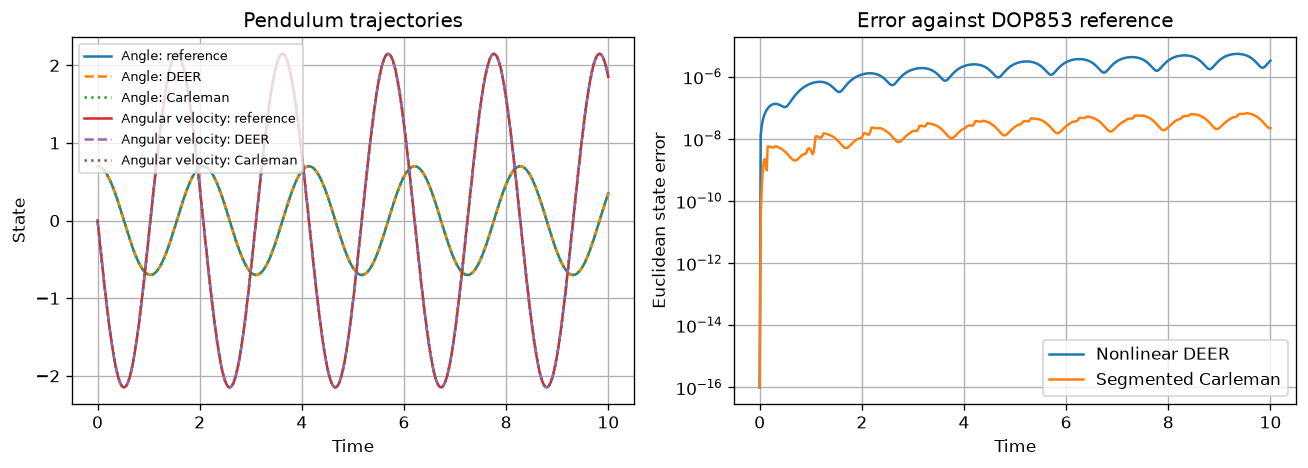

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for state_index, label in enumerate(("Angle", "Angular velocity")):
    axes[0].plot(times, reference[:, state_index], label=f"{label}: reference")
    axes[0].plot(times, nonlinear_states[:, state_index], "--", label=f"{label}: DEER")
    axes[0].plot(times, carleman_states[:, state_index], ":", label=f"{label}: Carleman")
nonlinear_error = np.linalg.norm(nonlinear_states - reference, axis=1)
carleman_error = np.linalg.norm(carleman_states - reference, axis=1)
axes[0].set_xlabel("Time")
axes[0].set_ylabel("State")
axes[0].set_title("Pendulum trajectories")
axes[0].legend(fontsize=8)
axes[1].semilogy(times, np.maximum(nonlinear_error, 1e-16), label="Nonlinear DEER")
axes[1].semilogy(times, np.maximum(carleman_error, 1e-16), label="Segmented Carleman")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Euclidean state error")
axes[1].set_title("Error against DOP853 reference")
axes[1].legend()
plt.tight_layout()
plt.show()


## Truncation-order study

,Order,Lifted dimension,Maximum error,RMS error,Final error
0,4,14,2.671036e-02,1.216446e-02,1.806218e-02
1,6,27,2.533258e-04,1.207826e-04,1.001764e-04
2,8,44,8.058761e-06,3.681160e-06,4.528529e-06
3,10,65,6.669904e-08,3.165765e-08,2.197368e-08


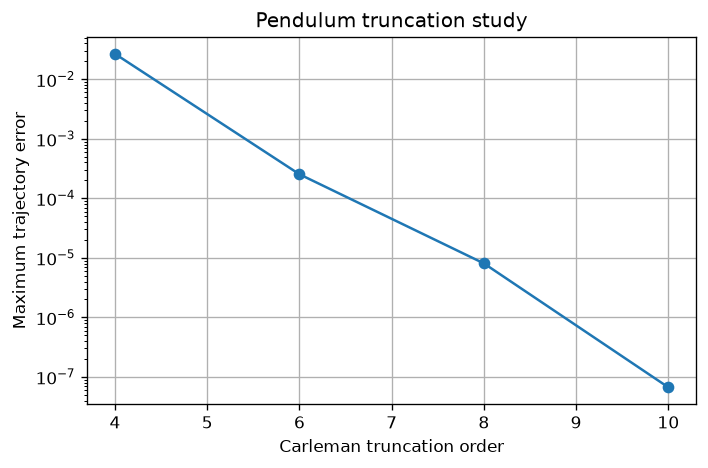

In [8]:
order_records = []
for order in (4, 6, 8, 10):
    matrix = pendulum_carleman_matrix(order)
    estimate = segmented_linear_trajectory(
        matrix=matrix,
        lift_function=lambda state, order=order: pendulum_lift(state, order),
        initial_state=x0_tensor,
        output_dimension=2,
        relift_steps=carleman_relift_steps,
    ).cpu().numpy()
    metrics = trajectory_metrics(estimate, reference)
    order_records.append({
        "Order": order,
        "Lifted dimension": matrix.shape[0],
        "Maximum error": metrics["Maximum error"],
        "RMS error": metrics["RMS error"],
        "Final error": metrics["Final error"],
    })
order_table = pd.DataFrame(order_records)
display(order_table.style.format({
    "Maximum error": "{:.6e}",
    "RMS error": "{:.6e}",
    "Final error": "{:.6e}",
}))
plt.figure(figsize=(6, 4))
plt.semilogy(order_table["Order"], order_table["Maximum error"], "o-")
plt.xlabel("Carleman truncation order")
plt.ylabel("Maximum trajectory error")
plt.title("Pendulum truncation study")
plt.tight_layout()
plt.show()
